The first thing I will do is export the currently required libraries and load the train.csv input data.



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df=pd.read_csv('train.csv',delimiter=',')
pd.read_csv('train.csv',delimiter=',')[:5]
print(df.shape)

(37137, 10)


## Let's build a diagram to check if there are NaN values in the dataset

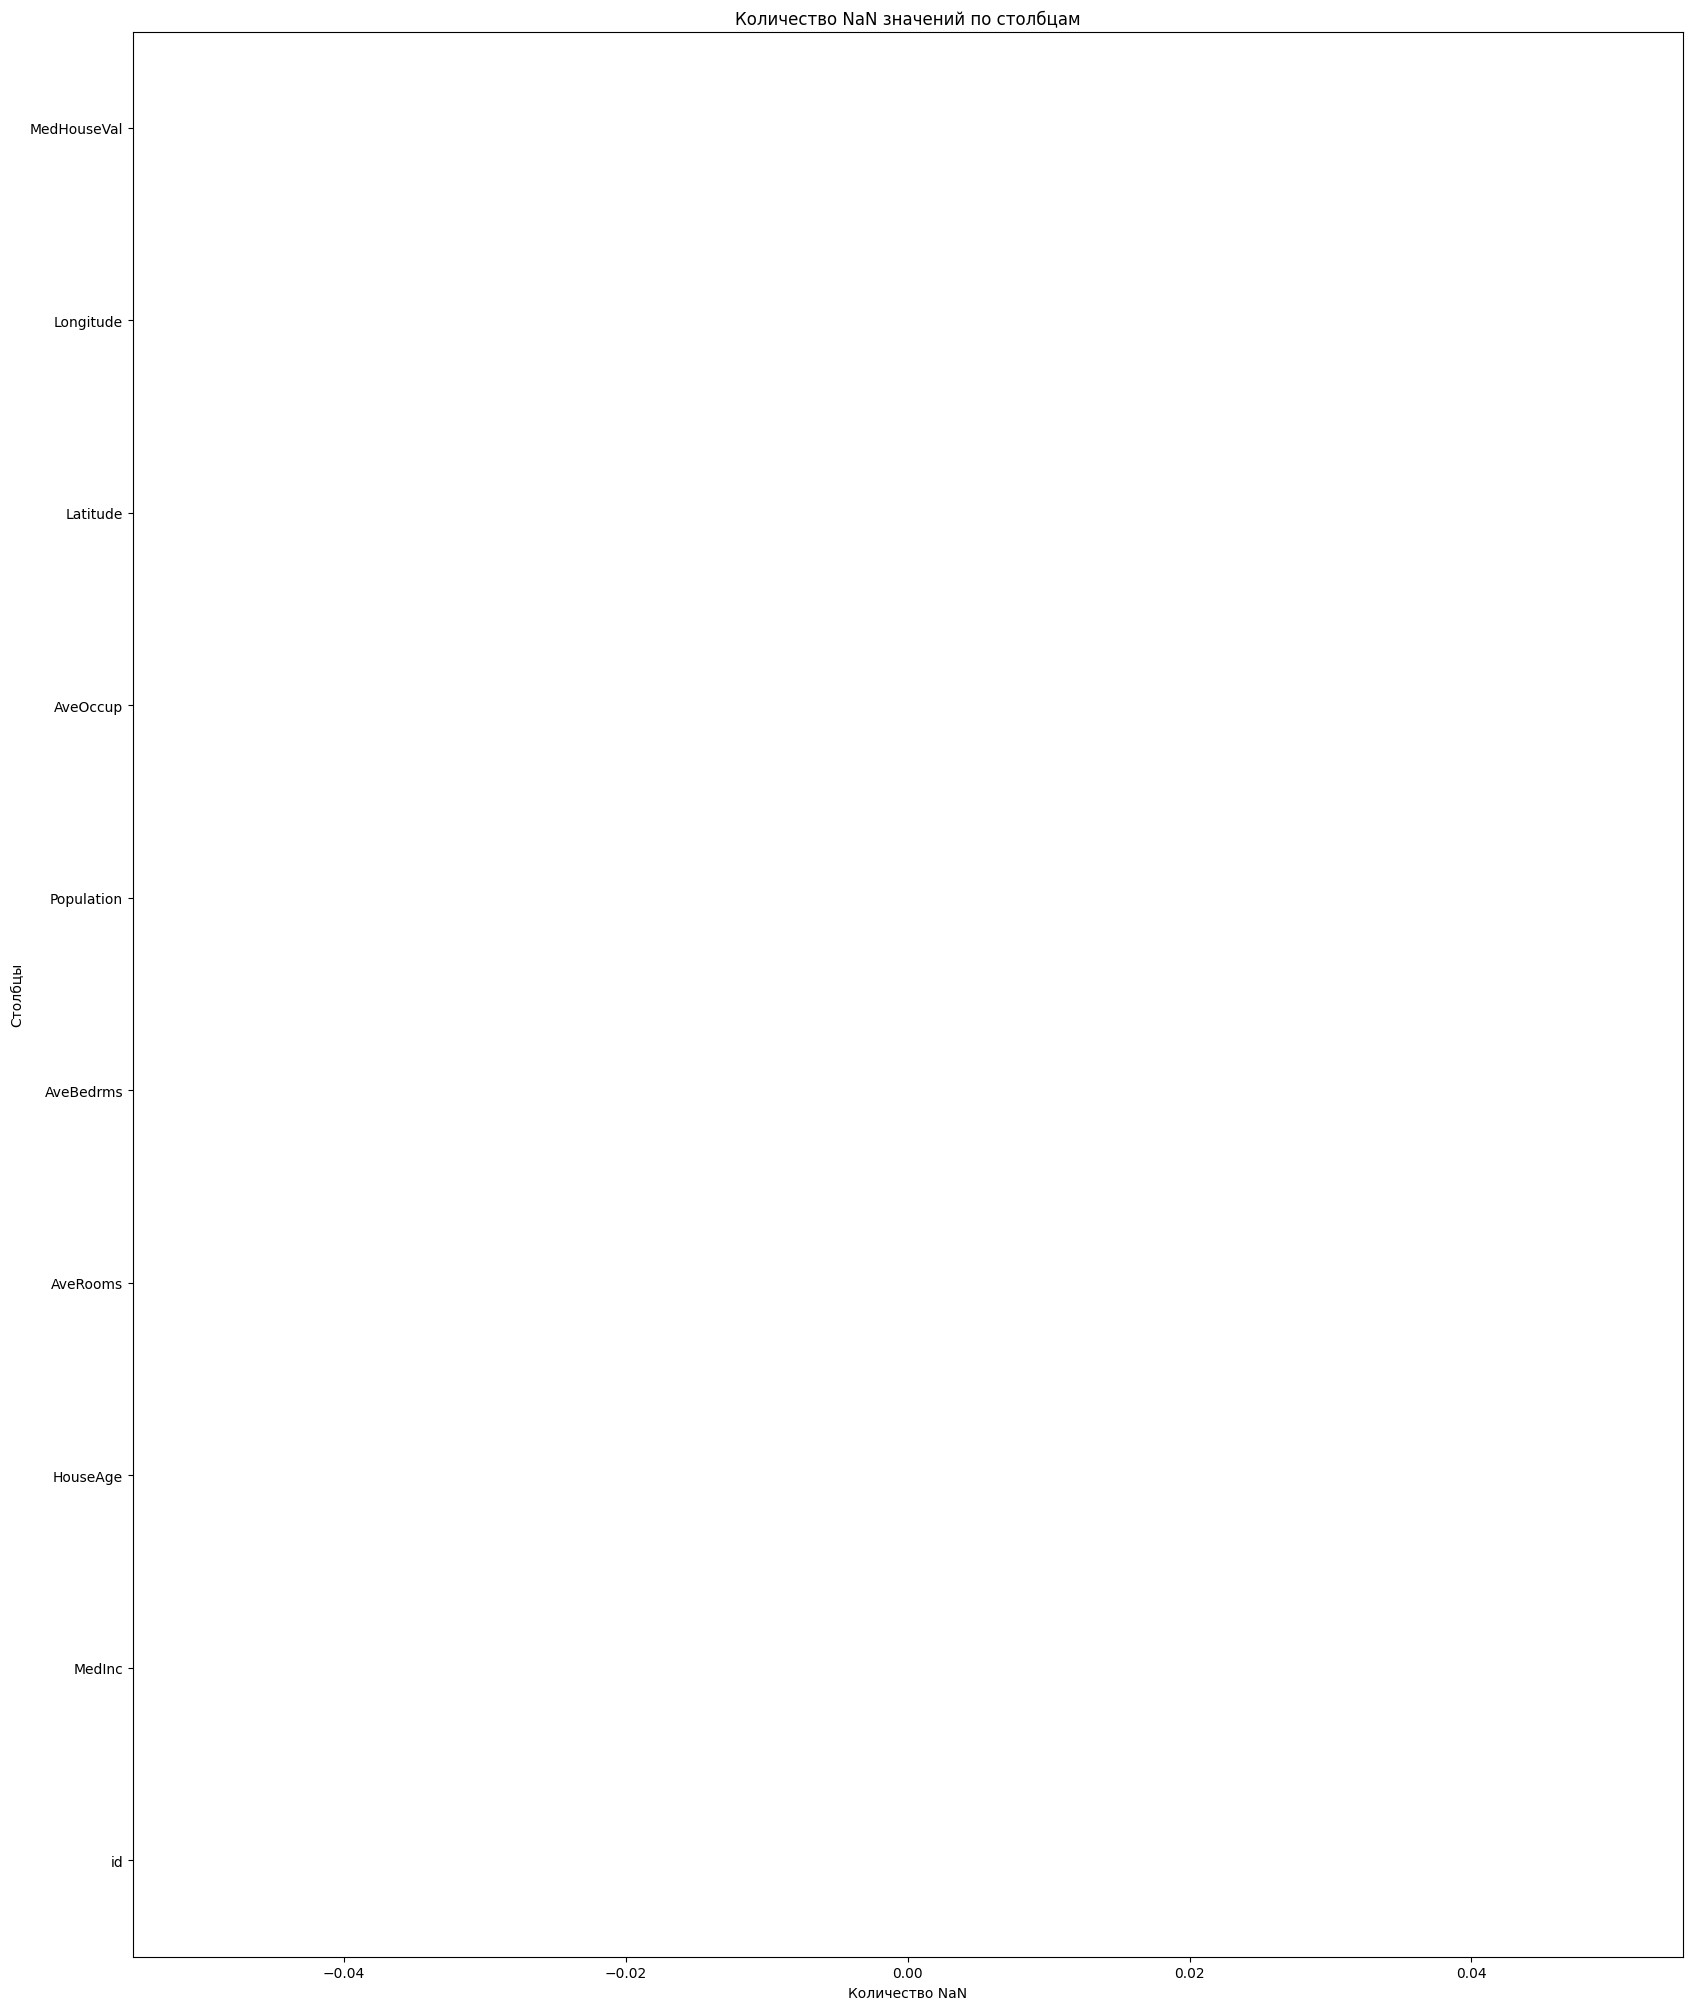

id             0
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [3]:

# Построим диаграмму, что проверить есть NaN значения в датасете

fig = plt.figure(figsize=(20, 25))

# Подсчёт количество NaN значений в каждом столбце
nan_counts = df.isna().sum()

nan_counts.plot(kind='barh')  # Используем barh для горизонтального столбчатого графика
plt.title('Количество NaN значений по столбцам')
plt.ylabel('Столбцы')
plt.xlabel('Количество NaN')

# Устанавливаем вертикальные подписи снизу по оси y
plt.xticks(rotation=0)
plt.show()

# Видим, что в нашем датасете нет NaN значений, но ещё раз перепроверим
print(nan_counts)
# Теперь мы уверены, что в датасете нет NaN значений



In [4]:
df.dtypes

id               int64
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

## After viewing the dataset and after displaying the data types in the dataset, it is clear that there are no categorical of data, however, let's make sure of this again by another method

In [5]:
# Просмотрев датасет и после вывода типов данных в датасете, видно, что в нём нет категориальных
# данных, однако убедимся в этом ещё раз другим методом

# Определям типы признаков числовые и категориальные
numeric_features = df.select_dtypes(include=['int', 'float']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical signs:", numeric_features)
print("Categorical features:", categorical_features)

# Теория подтвердилась, в датасете нет категориальных признаков

Numerical signs: Index(['id', 'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
       'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
Categorical features: Index([], dtype='object')


##Data preparation


In [6]:

y=np.array(df[['MedHouseVal']])
# Преобраз в одномерный массив
ytrain = y.ravel()

xtrain=df.drop(columns=['MedHouseVal'])

ytest=np.array(df[['MedHouseVal']])
xtest=df.drop(columns=['MedHouseVal'])

print(xtrain.shape)
print(xtest.shape)

(37137, 9)
(37137, 9)


#Training and performance evaluation of the trained model

RMSE: 0.726984254675617


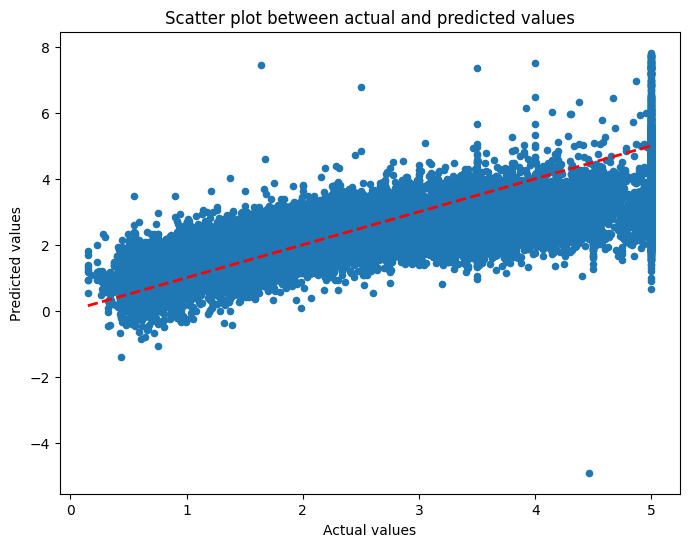

In [7]:
from math import sqrt
# Создание и обучение модели линейной регрессии
model = LinearRegression()


xtrain['sqrt_AveRooms'] = xtrain['AveRooms'].apply(lambda x: x ** 0.5)
xtrain['AveRooms_1'] = xtrain['AveRooms'].apply(lambda x: x ** 2)
xtrain['AveRooms_and_HouseAge'] = xtrain['AveRooms']*xtrain['HouseAge']
xtrain['AveRooms_and_HouseAge_sqr'] = xtrain['AveRooms_and_HouseAge'].apply(lambda x: x ** 0.5)
xtrain['AveRooms_and_HouseAge_sqr'] = xtrain['AveRooms_and_HouseAge'].apply(lambda x: x ** 2)




model.fit(xtrain, ytrain)
xtest['sqrt_AveRooms'] = xtest['AveRooms'].apply(lambda x: x ** 0.5)
xtest['AveRooms_1'] = xtest['AveRooms'].apply(lambda x: x ** 2)
xtest['AveRooms_and_HouseAge'] = xtest['AveRooms']*xtrain['HouseAge']
xtest['AveRooms_and_HouseAge_sqr'] = xtest['AveRooms_and_HouseAge'].apply(lambda x: x ** 0.5)
xtest['AveRooms_and_HouseAge_sqr'] = xtest['AveRooms_and_HouseAge'].apply(lambda x: x ** 2)
# Предсказание на обучающем наборе
ypred = model.predict(xtest)

# Оценка производительности модели на обучающих данных
rmse = sqrt(mean_squared_error(ytest, ypred))
print(f'RMSE: {rmse}')


# Построение графика рассеяния
plt.figure(figsize=(8, 6))
plt.scatter(y, ypred, s=20)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Scatter plot between actual and predicted values")
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', linewidth=2)
plt.show()
#RMSE: 0.7290320061556523
#RMSE: 0.7283981359912459
#RMSE: 0.7269856310451548

#Work with te original dataset  California Housing Dataset.



In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Загружаем California Housing Dataset
california_housing = fetch_california_housing()

# Создаем DataFrame из признаков (X)
X = pd.DataFrame(data=california_housing.data, columns=california_housing.feature_names)
(print(X.head))
# Создаем DataFrame из целевой переменной (y)
y = pd.DataFrame(data=california_housing.target, columns=['target'])

X = pd.concat([X, y], axis=1)

# Просмотрев датасет, видно, что в нём нет категориальных
# данных, однако проверим эту теорию

# Определям типы признаков числовые и категориальные
numeric_features_s = X.select_dtypes(include=['int', 'float']).columns
categorical_features_s = X.select_dtypes(include=['object']).columns


print("Numerical signs:", numeric_features_s)
print("Categorical features:", categorical_features_s)

# Теория подтвердилась, в датасете нет категориальных признаков


<bound method NDFrame.head of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Lo

# To increase the amount of data on which the model will be trained, I combine the datasets: submitted by assignment and from the library

In [9]:
print(numeric_features_s)
print(df.columns)

df=df.drop('id',axis=1)
# Проверяем совпадают ли столбцы
print(df.columns==X.columns)

#Столбцы не совпали по последнему значению: target и MedHouseVal, в датасете df поменяем название столбца
# MedHouseVal на target
df.columns = ['target' if col == 'MedHouseVal' else col for col in df.columns]

print(df.columns==X.columns)
# Столбцы совпали, значит можно объединить датасеты, чтобы обучающих данных было больше
# Строки с одинаковыми значениями не будут добавлены повторно в общий датасет, поэтому:
merged_df = pd.concat([df, X]).drop_duplicates().reset_index(drop=True)

# Выводим объединенный DataFrame
print(merged_df)


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')
Index(['id', 'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
       'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
[ True  True  True  True  True  True  True  True False]
[ True  True  True  True  True  True  True  True  True]
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      2.3859      15.0  3.827160   1.112100      1280.0  2.486989     34.60   
1      3.7188      17.0  6.013373   1.054217      1504.0  3.813084     38.69   
2      4.7750      27.0  6.535604   1.103175      1061.0  2.464602     34.71   
3      2.4138      16.0  3.350203   0.965432      1255.0  2.089286     32.66   
4      3.7500      52.0  4.284404   1.069246      1793.0  1.604790     37.80   
...       ...       ...       ...        ...         ...       ...       ...   
57772  1.5603      25.0  5.

##Task 7. Data preparation, model training and output of results

(57777,)
(57777, 9)
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
18054  3.6505       9.0  5.975913   1.011527      4656.0  2.941374     38.71   
45757  6.3021      24.0  5.763838   1.033210      1312.0  2.420664     33.86   
34963  2.7222      17.0  5.781690   1.211009       595.0  2.044304     35.35   
49645  5.1169      52.0  6.390400   1.016000      1295.0  2.072000     38.57   
30912  1.5536      37.0  2.532500   0.985000      1411.0  3.445000     33.80   
...       ...       ...       ...        ...         ...       ...       ...   
54343  2.5694      27.0  3.143770   0.955272       777.0  2.482428     34.43   
38158  5.9800      22.0  6.586470   0.990143      6693.0  2.998656     37.66   
860    2.1979      21.0  4.722298   1.039690      1614.0  2.432316     34.58   
15795  2.1449      21.0  5.017953   1.026930      1413.0  2.072797     38.49   
56422  2.6667      36.0  5.092357   1.098726      1086.0  3.458599     38.43   

       Longitude  


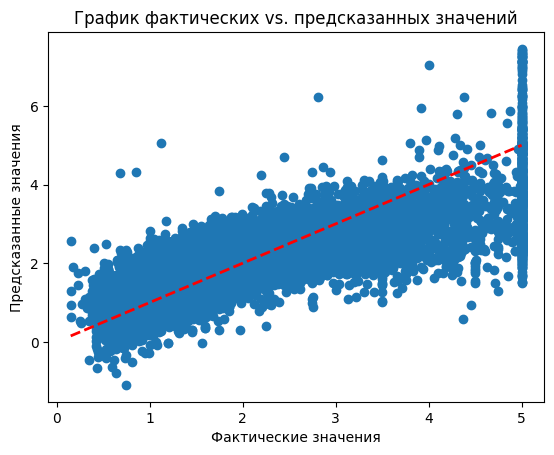

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
13267  1.7297      22.0  3.819071   1.004890      2313.0  2.187919     33.90   
50068  5.2590      13.0  6.733133   1.032984      1657.0  2.484258     38.64   
41330  3.1806      41.0  4.043333   1.003333       801.0  2.670000     34.12   
54959  7.0735      14.0  8.056485   1.117155      2052.0  4.292887     37.38   
476    4.7276      25.0  5.341176   1.000000       769.0  2.735294     37.29   
...       ...       ...       ...        ...         ...       ...       ...   
54180  6.5475      25.0  6.992374   1.102955      2626.0  2.503337     37.49   
2906   4.1587      38.0  5.838710   0.987097       820.0  2.161290     34.05   
50127  5.7133      13.0  6.756250   1.016667      1585.0  3.302083     38.70   
46908  3.3289      39.0  5.580488   1.290244      1449.0  3.534146     36.38   
24477  2.1806      25.0  2.848806   1.098160      1382.0  2.557545     34.10   

       Longitude  sqrt_AveRooms  AveRoo

In [10]:


y=np.array(merged_df[['target']])
# Преобраз в одномерный массив
y = y.ravel()
print(y.shape)
print(merged_df.shape)

x=merged_df.drop("target",axis=1)




X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train)
X_train['sqrt_AveRooms'] = X_train['AveRooms'].apply(lambda x: x ** 0.5)
X_train['AveRooms_1'] = X_train['AveRooms'].apply(lambda x: x ** 2)
X_train['AveRooms_and_HouseAge'] = X_train['AveRooms']*X_train['HouseAge']
X_train['AveRooms_and_HouseAge_sqr'] = X_train['AveRooms_and_HouseAge'].apply(lambda x: x ** 0.5)
X_train['AveRooms_and_HouseAge_sqr'] = X_train['AveRooms_and_HouseAge'].apply(lambda x: x ** 2)



X_test['sqrt_AveRooms'] =  X_test['AveRooms'].apply(lambda x: x ** 0.5)
X_test['AveRooms_1'] =  X_test['AveRooms'].apply(lambda x: x ** 2)
X_test['AveRooms_and_HouseAge'] = X_test['AveRooms']*X_test['HouseAge']
X_test['AveRooms_and_HouseAge_sqr'] = X_test['AveRooms_and_HouseAge'].apply(lambda x: x ** 0.5)
X_test['AveRooms_and_HouseAge_sqr'] = X_test['AveRooms_and_HouseAge'].apply(lambda x: x ** 2)



print(X_test)

# Создание и обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказание на обучающем наборе
ypred = model.predict(X_test)

# Оценка производительности модели
rmse = sqrt(mean_squared_error(y_test, ypred))
print(f'RMSE: {rmse}')

# Создание графика
plt.scatter(y_test, ypred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('График фактических vs. предсказанных значений')
plt.show()
print(X_test)


#An attempt to optimize the linear regression model


In [11]:
# Погуглив нашла пример оптимизации лин регр, пробую применить и оценить результат
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

## Now let's test

RMSE: 0.7180211367531689


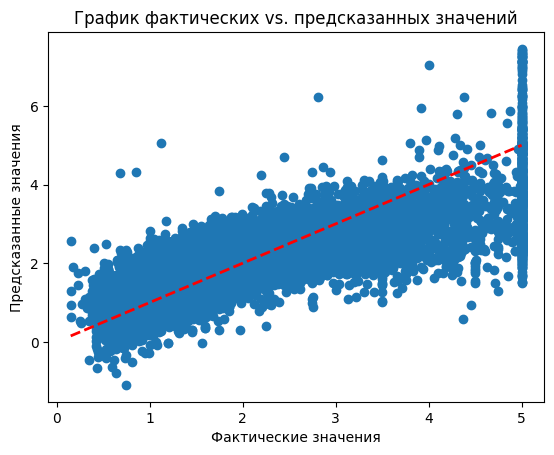

In [12]:
regression_pipeline.fit(X_train,y_train)
y_pred = regression_pipeline.predict(X_test)
# Оценка производительности модели
rmse = sqrt(mean_squared_error(y_test, ypred))
print(f'RMSE: {rmse}')

# Создание графика
plt.scatter(y_test, ypred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('График фактических vs. предсказанных значений')
plt.show()
#Видя RMSE:0.7181737851155854, можно сделать вывод, что ничего не изменилось от этих улучшений

# Let's try the model refinement method to understand if some column on the contrary makes it difficult for the model to work.

In [13]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt


selected_features = []
best_rmse = float('inf')

for feature in X_train.columns:
    current_features = selected_features + [feature]

    # Обучаем модель
    model = sm.OLS(y_train, sm.add_constant(X_train[current_features])).fit()

    # Получаем предсказания на тестовом наборе
    y_pred = model.predict(sm.add_constant(X_test[current_features]))

    # Оцениваем качество модели
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    # Сравниваем с текущим лучшим результатом
    if rmse < best_rmse:
        best_rmse = rmse
        selected_features = current_features

print("Лучший набор признаков:", selected_features)
print("RMSE лучшей модели:", best_rmse)


print(X_train.columns)


Лучший набор признаков: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'sqrt_AveRooms', 'AveRooms_1', 'AveRooms_and_HouseAge']
RMSE лучшей модели: 0.7175251533580315
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'sqrt_AveRooms', 'AveRooms_1',
       'AveRooms_and_HouseAge', 'AveRooms_and_HouseAge_sqr'],
      dtype='object')


# Let's start learning in the order of 2000 lines of regressions to choose the best one

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

# Создаем пример DataFrame
# Предположим, у вас есть DataFrame 'df' с признаками и целевой переменной 'target'

# Инициализируем переменные для сохранения лучшей модели
best_rmse = float('inf')
best_model = None

# Повторяем обучение 2000 раз, чтобы найти лучшую модель
for _ in range(2000):

    # Создаем и обучаем модель линейной регрессии
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Получаем предсказания на тестовом наборе
    y_pred = model.predict(X_test)

    # Оцениваем качество модели
    rmse = sqrt(mean_squared_error(y_test, y_pred))

    # Сравниваем с текущим лучшим результатом
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model

# Выводим параметры лучшей модели
print("Лучшие параметры модели:")
print("Коэффициенты (веса):", best_model.coef_)
print("RMSE лучшей модели:", best_rmse)



Лучшие параметры модели:
Коэффициенты (веса): [ 4.60495001e-01  5.80378360e-03  1.50178893e-01  6.24072795e-01
 -1.07328734e-05 -5.35541946e-03 -4.13571190e-01 -4.27308667e-01
 -1.22396130e+00 -2.64910655e-03  1.89065366e-04  1.20889867e-06]
RMSE лучшей модели: 0.7180211367531689


##Now let's choose the best model

In [15]:
if best_rmse>rmse:
    best_model=model

In [16]:
coefficients = best_model.coef_
print(coefficients)


df=pd.read_csv('test.csv',delimiter=',')
pd.read_csv('test.csv',delimiter=',')[:5]
# Предсказание на обучающем наборе


file=pd.read_csv("test.csv")

new_df = df[['id']].copy()

file.drop(columns=['id'], inplace=True)
file['sqrt_AveRooms'] =  file['AveRooms'].apply(lambda x: x ** 0.5)
file['AveRooms_1'] =  file['AveRooms'].apply(lambda x: x ** 2)
file['AveRooms_and_HouseAge'] = file['AveRooms']*file['HouseAge']
file['AveRooms_and_HouseAge_sqr'] = file['AveRooms_and_HouseAge'].apply(lambda x: x ** 0.5)
file['AveRooms_and_HouseAge_sqr'] = file['AveRooms_and_HouseAge'].apply(lambda x: x ** 2)

print(file)

ypred = best_model.predict(file)

#result = pd.DataFrame({'Id': new_df['id'], 'MedHouseVal': ypred})


#result.to_csv('solution.csv', index=False)
print(X_test)

[ 4.60495001e-01  5.80378360e-03  1.50178893e-01  6.24072795e-01
 -1.07328734e-05 -5.35541946e-03 -4.13571190e-01 -4.27308667e-01
 -1.22396130e+00 -2.64910655e-03  1.89065366e-04  1.20889867e-06]
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      1.7062      35.0  4.966368   1.096539      1318.0  2.844411     39.75   
1      1.3882      22.0  4.187035   1.098229      2296.0  3.180218     33.95   
2      7.7197      21.0  7.129436   0.959276      1535.0  2.888889     33.61   
3      4.6806      49.0  4.769697   1.048485       707.0  1.743590     34.17   
4      3.1284      25.0  3.765306   1.081633      4716.0  2.003827     34.17   
...       ...       ...       ...        ...         ...       ...       ...   
24754  2.2875      34.0  3.914729   1.085271       866.0  2.071429     34.44   
24755  3.0781      33.0  4.771971   1.038674      1628.0  2.326848     34.09   
24756  2.6961      14.0  4.593960   1.170380      3900.0  2.540034     37.51   
2475

##Because now you can use not only linear regression. Then I will use gradient boosting to train a new model

In [29]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

print(X_test)

# Создаем модель градиентного бустинга для регрессии
#RMSE: 0.5286278253387019
#model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.2, max_depth=7, random_state=42)
#RMSE: 0.5334194555901479
#model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.2, max_depth=7, random_state=42)
#0.58
#model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.4, max_depth=11, random_state=42)

#RMSE: 0.5386382453744303
#model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=11, random_state=42)
#RMSE: 0.5473527519743896
#model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.2, max_depth=9, random_state=42)

#RMSE: 0.5366068386671409
#model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.2, max_depth=8, random_state=42)

#RMSE: 0.5279977541109045
#model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.2, max_depth=6, random_state=42)

#RMSE: 0.5267604301874186
#model = GradientBoostingRegressor(n_estimators=170, learning_rate=0.2, max_depth=5, random_state=42)

#RMSE: 0.5287436532307225
#model = GradientBoostingRegressor(n_estimators=190, learning_rate=0.2, max_depth=6, random_state=42)

#RMSE: 0.5332121844504377
#model = GradientBoostingRegressor(n_estimators=190, learning_rate=0.2, max_depth=7, random_state=42)

#RMSE: 0.5267881126313837
#model = GradientBoostingRegressor(n_estimators=180, learning_rate=0.2, max_depth=5, random_state=42)

#RMSE: 0.5285564973306851
#model = GradientBoostingRegressor(n_estimators=170, learning_rate=0.2, max_depth=6, random_state=42)


# Обучаем модель на обучающем датасете
model.fit(X_train, y_train)

# Делаем предсказания на тестовом датасете
predictions = model.predict(X_test)
print(X_test)

# Оцениваем качество модели
mse = mean_squared_error(y_test, predictions)**0.5
print(f"RMSE: {mse}")

res = model.predict(file)

result = pd.DataFrame({'Id': new_df['id'], 'MedHouseVal': res})


result.to_csv('solution.csv', index=False)


       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
13267  1.7297      22.0  3.819071   1.004890      2313.0  2.187919     33.90   
50068  5.2590      13.0  6.733133   1.032984      1657.0  2.484258     38.64   
41330  3.1806      41.0  4.043333   1.003333       801.0  2.670000     34.12   
54959  7.0735      14.0  8.056485   1.117155      2052.0  4.292887     37.38   
476    4.7276      25.0  5.341176   1.000000       769.0  2.735294     37.29   
...       ...       ...       ...        ...         ...       ...       ...   
54180  6.5475      25.0  6.992374   1.102955      2626.0  2.503337     37.49   
2906   4.1587      38.0  5.838710   0.987097       820.0  2.161290     34.05   
50127  5.7133      13.0  6.756250   1.016667      1585.0  3.302083     38.70   
46908  3.3289      39.0  5.580488   1.290244      1449.0  3.534146     36.38   
24477  2.1806      25.0  2.848806   1.098160      1382.0  2.557545     34.10   

       Longitude  sqrt_AveRooms  AveRoo